##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
# Provide your solution here
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from torchvision.datasets import OxfordIIITPet
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T

/opt/anaconda3/envs/cv_lab1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_ID = "facebook/dinov2-small"
device   = "cuda" if torch.cuda.is_available() else "cpu"
NUM_IMAGES  = 20
NUM_CLUSTERS = 2

In [3]:
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f"Model loaded on {device}")

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 7292.34it/s]

Model loaded on cpu


In [5]:
dataset = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="binary-category",
    download=True,
    transform=T.ToTensor()
)
indices = list(range(0, len(dataset), len(dataset) // NUM_IMAGES))[:NUM_IMAGES]

100%|██████████| 792M/792M [24:40<00:00, 535kB/s]    
100%|██████████| 19.2M/19.2M [00:30<00:00, 626kB/s]


In [6]:
embeddings   = []
ground_truth = []   # 0 is cat, 1 is dog
 
for idx in indices:
    img_tensor, label = dataset[idx]
    img_pil = T.ToPILImage()(img_tensor).convert("RGB")
    inputs  = processor(images=img_pil, return_tensors="pt").to(device)
 
    with torch.no_grad():
        outputs   = model(**inputs)
        cls_token = outputs.last_hidden_state[:, 0]
        cls_norm  = F.normalize(cls_token, p=2, dim=1)
 
    embeddings.append(cls_norm.squeeze().cpu().numpy())
    ground_truth.append(label)
 
embeddings   = np.array(embeddings)
ground_truth = np.array(ground_truth)  

In [7]:
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(embeddings)

In [9]:
acc_direct = np.mean(predicted_clusters == ground_truth)
acc_flipped = np.mean((1 - predicted_clusters) == ground_truth)
accuracy = max(acc_direct, acc_flipped)
 
print(f"Ground truth : {ground_truth.tolist()}")
print(f"Predicted    : {predicted_clusters.tolist()}")
print(f"Accuracy     : {accuracy * 100:.1f}%")

Ground truth : [0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1]
Predicted    : [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1]
Accuracy     : 65.0%


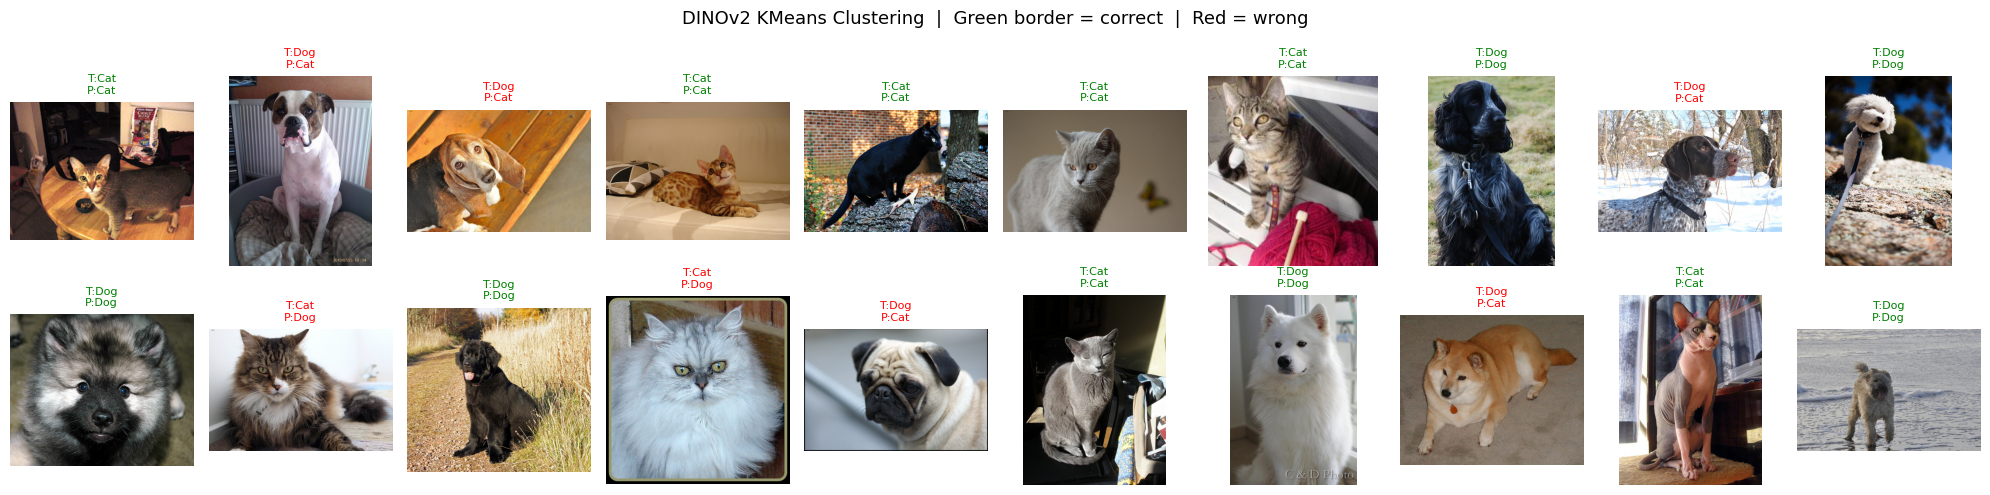

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle("DINOv2 KMeans Clustering  |  Green border = correct  |  Red = wrong",
             fontsize=13)
 
label_names = {0: "Cat", 1: "Dog"}
use_flipped = acc_flipped > acc_direct
 
for i, ax in enumerate(axes.flat):
    img_tensor, true_label = dataset[indices[i]]
    img_pil = T.ToPILImage()(img_tensor)
    ax.imshow(img_pil)
    ax.axis("off")
 
    pred = int(predicted_clusters[i])
    if use_flipped:
        pred = 1 - pred
    true = int(ground_truth[i])
    color = "green" if pred == true else "red"
    ax.set_title(f"T:{label_names[true]}\nP:{label_names[pred]}",
                 fontsize=8, color=color)
 
plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [11]:
# Provide your solution here
from transformers import AutoImageProcessor, AutoModelForImageClassification
import requests
from io import BytesIO

In [12]:
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device   = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f"Model loaded on {device}")

Loading weights: 100%|██████████| 225/225 [00:00<00:00, 14095.24it/s]

Model loaded on cpu


In [20]:
img = Image.open("/Users/ykalsuhaili/Documents/GitHub/arti560-computer-vision-labs/lab10-visual-representations/data/Golden-Retriever.jpg").convert("RGB")

In [21]:
inputs = processor(images=img, return_tensors="pt").to(device)
 
with torch.no_grad():
    outputs = model(**inputs)
    logits  = outputs.logits

In [22]:
probs      = F.softmax(logits, dim=1)[0]
top5_probs, top5_ids = torch.topk(probs, 5)

labels = model.config.id2label
 
print("\ntop 5 predictions")
for rank, (prob, idx) in enumerate(zip(top5_probs, top5_ids)):
    print(f"  {rank+1}. {labels[idx.item()]:40s}  {prob.item()*100:5.2f}%")


top 5 predictions
  1. golden retriever                          98.02%
  2. clumber, clumber spaniel                   0.50%
  3. Labrador retriever                         0.35%
  4. kuvasz                                     0.31%
  5. Great Pyrenees                             0.14%


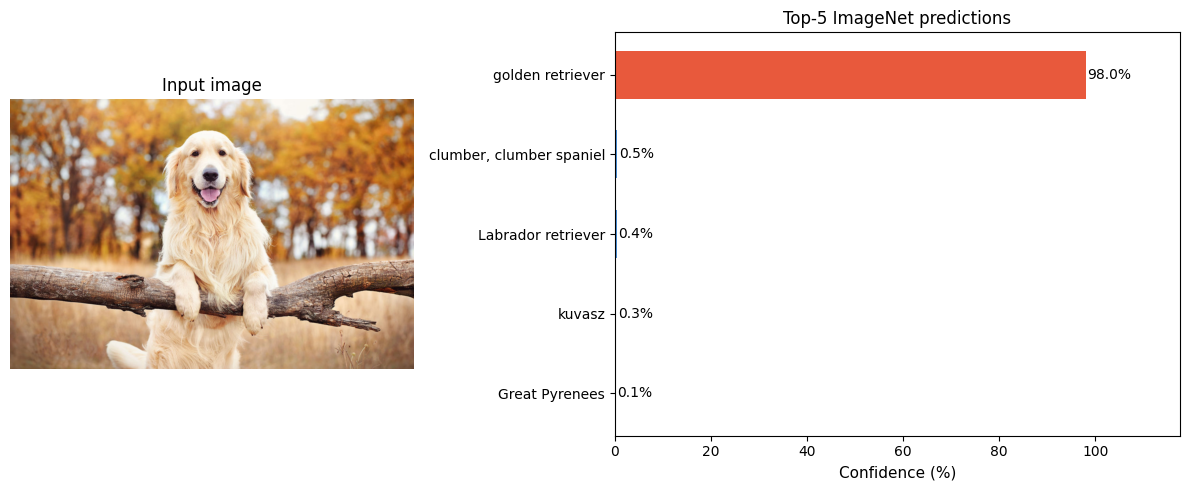

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.4]})
 
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title("Input image", fontsize=12)
 
names = [labels[i.item()] for i in top5_ids]
values = [p.item() * 100 for p in top5_probs]
colors = ["#4A90D9" if j > 0 else "#E8593C" for j in range(5)]
 
bars = axes[1].barh(names[::-1], values[::-1], color=colors[::-1], height=0.6)
axes[1].set_xlabel("Confidence (%)", fontsize=11)
axes[1].set_title("Top-5 ImageNet predictions", fontsize=12)
axes[1].set_xlim(0, max(values) * 1.2)
 
for bar, val in zip(bars, values[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10)
 
plt.tight_layout()
plt.show()